# Clase 08 - Analisis de Datos

bla bla

## Librerias

---


In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import re
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder
import math
from sklearn.mixture import GaussianMixture

## Paso 2 - Lectura de datos

---

In [7]:
df = pd.read_csv("../INPUTS/computer_prices_all.csv", encoding="utf-8")

display(df)

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,ASUS,ASUS Pro ZWL,2023,Windows,Mainstream,Intel,Intel i7-13721,4,12,...,1920x1080,144,90,180,0,Wi-Fi 6,5.1,1.87,24,1712.99
99996,Laptop,Lenovo,Lenovo Stealth 014,2018,Windows,Ultrabook,AMD,AMD Ryzen 5 5117,2,8,...,2560x1600,90,50,65,0,Wi-Fi 6,5.1,1.37,12,1258.99
99997,Laptop,ASUS,ASUS Zen LKD,2020,Windows,Mainstream,Intel,Intel i5-12677,2,6,...,2560x1600,120,99,180,0,Wi-Fi 6,4.2,1.17,12,1686.99
99998,Laptop,ASUS,ASUS Blade DH6,2020,Windows,Mainstream,AMD,AMD Ryzen 7 4590,4,12,...,2560x1600,120,60,90,0,Wi-Fi 6,5.3,1.70,24,2164.99


## Paso 1 - Descripcion de variables y variable objetivo

---

The dataset contains ~100,000 rows of PCs and laptops with around 30 specifications, including:

- Device type: Laptop / Desktop
- CPU: brand, model, cores, threads, base/boost clock
- GPU: brand, model, VRAM
- Memory: RAM size, storage type/size/drive count
- Display: type (LED, OLED, Mini-LED, IPS, VA, QLED), resolution, refresh rate, size
- Other features: release year, form factor, weight, PSU/battery, Wi-Fi, Bluetooth, warranty
- Target: price

Your challenge: build the best regression model to predict price as accurately as possible.

La variable objetivo es **el precio**.


## Paso 3 - Analisis exploratorio (EDA)

---

Para ver la cantidad de valores no nulos y los tipos de datos de las columnas del datagrame podemos usar el metodo .info(). Este metodo nos da la siguiente informacion:

- Cantidad de entradas del dataframe.
- Cantidad de entradas no nulas de cada columna.
- Tipo de dato de cada columna.
- Cantidad de columnas por tipo de dato.
- Uso de memoria.

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  cpu_base_ghz         100000 non-null  float64
 12  cpu_boost_ghz        100000 non-null  float64
 13  gpu_brand            100000 non-null  object 
 14  gpu_model            100000 non-null  object 
 15  gpu_tier          

None

Para vizualizar la cantidad de columnas por tipo de dato, tambien podemos hacer:

In [12]:
df.dtypes.value_counts()

int64      14
object     13
float64     6
Name: count, dtype: int64

Para ver la cantidad de valores unicos por columna, podemos usar el metodo `nunique`, ordenando los valores en forma descendiente.

In [15]:
# valores unicos por columna

df.nunique().sort_values(ascending=False)

model                  99036
cpu_model              26971
price                   3366
gpu_model                 49
weight_kg                 47
cpu_threads               25
cpu_boost_ghz             18
ram_gb                    15
cpu_cores                 12
brand                     10
form_factor               10
psu_watts                  9
display_size_in            9
battery_wh                 8
cpu_base_ghz               8
release_year               8
vram_gb                    8
charger_watts              7
cpu_tier                   6
resolution                 6
gpu_tier                   6
display_type               6
refresh_hz                 6
bluetooth                  5
storage_gb                 5
wifi                       4
storage_type               4
os                         4
gpu_brand                  4
warranty_months            4
storage_drive_count        4
cpu_brand                  3
device_type                2
dtype: int64

Una primera conclusion a la que podemos llegar, es que el campo `model` no servira para hacer analisis predictivos, pues apenas se cuenta con 1 o 2 observaciones para cada tipo de modelo. Lo mismo se puede concluir sobre`cpu_model`, pero en menor medida.

In [17]:
n_dup = df.duplicated().sum()
pct_sup = (n_dup / len(df) * 100) if len(df) > 0 else 0
print(f"Numero de filas duplicadas: {n_dup} ({pct_sup:.2f}%)")

Numero de filas duplicadas: 0 (0.00%)


In [ ]:
#PENDIENTE -------- 

In [23]:
# estadisitcas descriptivas de variables numericas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
base_num = df[numeric_cols]
n_rows = base_num.shape[0]
desc = base_num.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

desc["n_unicos"] = base_num.nunique()
desc["n_missings"] = base_num.isnull().sum()
desc["pct_missings"] = (desc["n_missings"] / n_rows * 100) if n_rows > 0 else 0
desc["skew"] = base_num.skew()
desc["kurt"] = base_num.kurtosis()


display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,n_unicos,n_missings,pct_missings,skew,kurt
release_year,100000.0,2022.320850,2.025761,2018.00,2018.00,2018.00,2021.00,2023.00,2024.00,2025.00,2025.00,2025.00,8,0,0.0,-0.479062,-0.715846
cpu_tier,100000.0,3.153490,1.373175,1.00,1.00,1.00,2.00,3.00,4.00,5.00,6.00,6.00,6,0,0.0,0.174307,-0.751699
cpu_cores,100000.0,10.515740,5.044092,4.00,4.00,4.00,6.00,8.00,14.00,20.00,26.00,28.00,12,0,0.0,1.087762,1.007646
cpu_threads,100000.0,19.372700,9.718426,4.00,6.00,8.00,12.00,16.00,24.00,36.00,52.00,56.00,25,0,0.0,1.125744,1.300012
cpu_base_ghz,100000.0,2.591322,0.336435,2.00,2.00,2.00,2.40,2.60,2.80,3.20,3.40,3.40,8,0,0.0,0.172064,-0.520792
cpu_boost_ghz,100000.0,3.531310,0.350024,2.80,2.80,3.00,3.30,3.50,3.80,4.10,4.30,4.50,18,0,0.0,0.149925,-0.451167
gpu_tier,100000.0,2.991350,1.459643,1.00,1.00,1.00,2.00,3.00,4.00,6.00,6.00,6.00,6,0,0.0,0.285752,-0.851269
vram_gb,100000.0,6.152180,3.964926,0.00,0.00,0.00,4.00,6.00,8.00,12.00,16.00,16.00,8,0,0.0,0.281362,-0.354864
ram_gb,100000.0,39.706400,31.902684,8.00,8.00,8.00,16.00,32.00,64.00,96.00,128.00,144.00,15,0,0.0,1.049278,0.195870
storage_gb,100000.0,903.936000,774.243654,256.00,256.00,256.00,512.00,512.00,1024.00,2048.00,4096.00,4096.00,5,0,0.0,2.304037,6.272154


Text(0.5, 1.0, 'Distribucion de vram_gb')

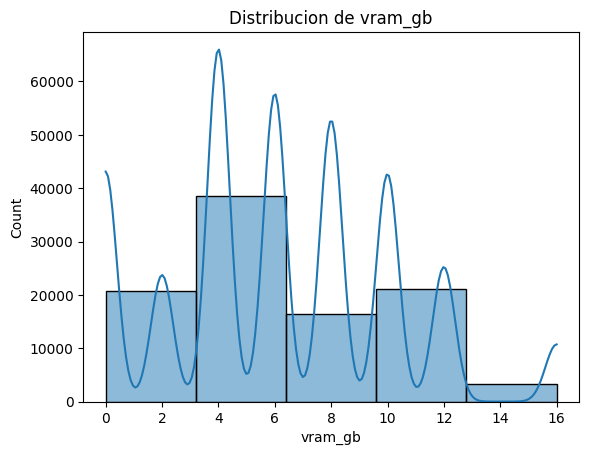

In [32]:
## Paso 4 - Feature engineering

#df.drop(columns=["model", "cpu_model"], inplace=True)   # Elminar columnas irrelevantes, con inplace true para modificar el dataframe original

sns.histplot(data=df, x="vram_gb", bins=5, kde=True)
plt.title("Distribucion de vram_gb")

El equivalente para variables categoricas son tablas de frecuencias:

In [ ]:
cat_types = ["object", "category", "bool", "string"]    # One hot encoding, transformacion de numerico a categorico

# Ordinal encoding, al transgformar el dato categorico a ordinal se da una ponderacion segun el orden.